#### Face verification system by Principal Component Analysis (PCA)

In [1]:
import scipy.io
data = scipy.io.loadmat('facedata.mat')
print(data['facedata'].shape)
print(data['facedata'][0,0])
print(data['facedata'][0,0].shape)

(40, 10)
[[48 46 50 ... 50 54 53]
 [47 47 48 ... 37 46 50]
 [46 48 43 ... 33 41 51]
 ...
 [49 49 50 ... 45 46 47]
 [48 48 49 ... 45 46 46]
 [51 48 50 ... 45 45 46]]
(56, 46)


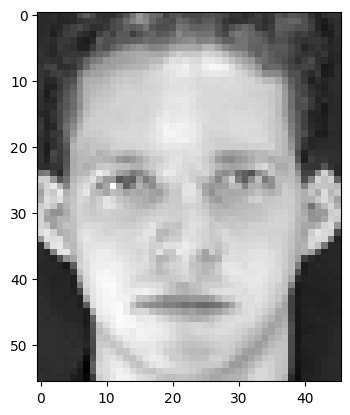

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.imshow(data['facedata'][0,0],cmap="gray")
plt.show()

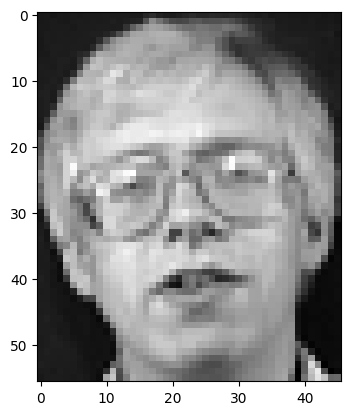

In [3]:
plt.imshow(data['facedata'][1,0],cmap="gray")
plt.show()

#### Working with images

Each pixel in an image is usually represented by a 8-bit unsigned integer (values from 0 to 255).
In order to easily work on images, we usually convert them to floats or doubles using the following
command.

In [4]:
from skimage import img_as_float
xf = {}
xf[0,0] = img_as_float(data['facedata'][0,0])
print(xf[0,0])

[[0.18823529 0.18039216 0.19607843 ... 0.19607843 0.21176471 0.20784314]
 [0.18431373 0.18431373 0.18823529 ... 0.14509804 0.18039216 0.19607843]
 [0.18039216 0.18823529 0.16862745 ... 0.12941176 0.16078431 0.2       ]
 ...
 [0.19215686 0.19215686 0.19607843 ... 0.17647059 0.18039216 0.18431373]
 [0.18823529 0.18823529 0.19215686 ... 0.17647059 0.18039216 0.18039216]
 [0.2        0.18823529 0.19607843 ... 0.17647059 0.17647059 0.18039216]]


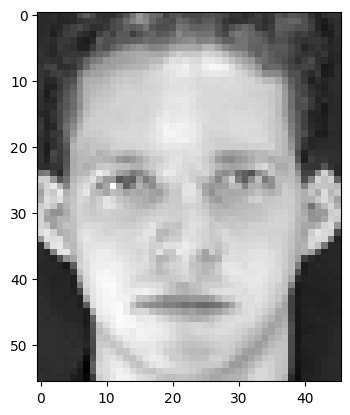

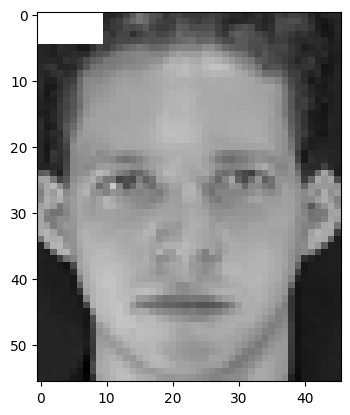

In [5]:
plt.imshow(xf[0,0],cmap="gray")
plt.show()
x_temp = xf[0,0].copy()
x_temp[0:5,0:10] = 1
# In float format, 1 is white
plt.imshow(x_temp,cmap="gray")
plt.show()

In [6]:
import numpy as np
xf[0,1] = img_as_float(data['facedata'][0,1])
distance = np.linalg.norm(xf[0,0].flatten() - xf[0,1].flatten())
print("Distance between face 0,0 and face 0,1:", distance)
xf[1,0] = img_as_float(data['facedata'][1,0])
distance = np.linalg.norm(xf[0,0].flatten() - xf[1,0].flatten())
print("Distance between face 0,0 and face 1,0:", distance)

Distance between face 0,0 and face 0,1: 10.037616294165492
Distance between face 0,0 and face 1,0: 8.173295099737281


In [7]:
import numpy as np

def compute_similarity_matrix(T, D):
    """
    Compute similarity matrix A where A[i,j] is the Euclidean distance
    between data sample i from list T and data sample j from list D.
    
    Parameters:
    T: List or array of data samples (shape: n_samples_T x features)
    D: List or array of data samples (shape: n_samples_D x features)
    
    Returns:
    A: Similarity matrix (shape: len(T) x len(D))
    """
    n_T = len(T)
    n_D = len(D)
    A = np.zeros((n_T, n_D))
    
    for i in range(n_T):
        for j in range(n_D):
            # Flatten samples and compute Euclidean distance
            A[i, j] = np.linalg.norm(T[i].flatten() - D[j].flatten())
    
    return A

In [8]:
# Load all images into xf dictionary
for person in range(40):
    for image in range(10):
        xf[person, image] = img_as_float(data['facedata'][person, image])

# Build training set T (first 3 images from each of 40 people)
T = []
for person in range(40):
    for image in range(3):
        T.append(xf[person, image])

# Build testing set D (images 3-9 from each of 40 people)
D = []
for person in range(40):
    for image in range(3, 10):
        D.append(xf[person, image])

# Compute similarity matrix A
A = compute_similarity_matrix(T, D)

print("Similarity matrix shape:", A.shape)
print("Training set size (T):", len(T))
print("Testing set size (D):", len(D))

# # Visualize the similarity matrix as an image
# plt.figure(figsize=(12, 10))
# plt.imshow(A, cmap='hot', aspect='auto')
# plt.colorbar(label='Euclidean Distance')
# plt.xlabel('Testing Images (D)')
# plt.ylabel('Training Images (T)')
# plt.title('Face Similarity Matrix (Euclidean Distance)')
# plt.tight_layout()
# plt.show()

Similarity matrix shape: (120, 280)
Training set size (T): 120
Testing set size (D): 280


In [9]:
print(A.shape)

(120, 280)


In [10]:
def compute_verification_rates(A, threshold):
    """
    Compute true positive rate and false alarm rate for face verification.
    
    Parameters:
    A: Similarity matrix (shape: 120 x 280) where A[i,j] is Euclidean distance
       between training image i and testing image j
    threshold: Distance threshold t for verification decision
    
    Returns:
    tpr: True positive rate (correctly identified faces from same person)
    far: False alarm rate (incorrectly identified faces from different person)
    """
    true_positives = 0
    false_alarms = 0
    total_genuine = 0
    total_impostor = 0
    
    # For each training image (person p, image i in range 0-2)
    for train_idx in range(120):
        person_train = train_idx // 3  # Which person (0-39)
        
        # For each testing image (person q, image j in range 3-9)
        for test_idx in range(280):
            person_test = test_idx // 7  # Which person (0-39)
            
            distance = A[train_idx, test_idx]
            
            if person_train == person_test:
                # Genuine comparison (same person)
                total_genuine += 1
                if distance < threshold:
                    true_positives += 1
            else:
                # Impostor comparison (different person)
                total_impostor += 1
                if distance < threshold:
                    false_alarms += 1
    
    # Compute rates
    tpr = true_positives / total_genuine if total_genuine > 0 else 0
    far = false_alarms / total_impostor if total_impostor > 0 else 0
    
    return tpr, far

# Compute verification rates for threshold t = 10
threshold = 10
tpr, far = compute_verification_rates(A, threshold)

print(f"Threshold t = {threshold}")
print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"False Alarm Rate (FAR): {far:.4f}")
print(f"True Positives: {tpr * (120 * 7 * 40):.0f} out of {120 * 7 * 40}")
print(f"False Alarms: {far * (120 * 3 * 40 * 39):.0f} out of {120 * 3 * 40 * 39}")

Threshold t = 10
True Positive Rate (TPR): 0.9714
False Alarm Rate (FAR): 0.3547
True Positives: 32640 out of 33600
False Alarms: 199217 out of 561600


In [11]:
import numpy as np

def verify_face(test_image, training_images, threshold):
    """
    Verify if a test image belongs to the same person as the training images.
    
    Parameters:
    test_image: The test image (numpy array)
    training_images: List of training images for the person (list of numpy arrays)
    threshold: Distance threshold t for verification
    
    Returns:
    bool: True if the minimum distance is below threshold (accepted as same person), False otherwise
    """
    distances = [np.linalg.norm(test_image.flatten() - train.flatten()) for train in training_images]
    min_distance = min(distances)
    return min_distance < threshold

In [ ]:
def compute_verification_rates(A, threshold):
    """
    Compute true positive rate and false alarm rate for face verification.
    
    Parameters:
    A: Similarity matrix (shape: 120 x 280) where A[i,j] is Euclidean distance
       between training image i and testing image j
    threshold: Distance threshold t for verification decision
    
    Returns:
    tpr: True positive rate (correctly identified faces from same person)
    far: False alarm rate (incorrectly identified faces from different person)
    """
    true_positives = 0
    false_alarms = 0
    total_genuine = 0
    total_impostor = 0
    
    # For each training image (person p, image i in range 0-2)
    for train_idx in range(120):
        person_train = train_idx // 3  # Which person (0-39)
        
        # For each testing image (person q, image j in range 3-9)
        for test_idx in range(280):
            person_test = test_idx // 7  # Which person (0-39)
            
            distance = A[train_idx, test_idx]
            
            if person_train == person_test:
                # Genuine comparison (same person)
                total_genuine += 1
                if distance < threshold:
                    true_positives += 1
            else:
                # Impostor comparison (different person)
                total_impostor += 1
                if distance < threshold:
                    false_alarms += 1
    
    # Compute rates
    tpr = true_positives / total_genuine if total_genuine > 0 else 0
    far = false_alarms / total_impostor if total_impostor > 0 else 0
    
    return tpr, far

# Compute verification rates for threshold t = 10
threshold = 10
tpr, far = compute_verification_rates(A, threshold)

print(f"Threshold t = {threshold}")
print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"False Alarm Rate (FAR): {far:.4f}")

Minimum threshold: 1.7420
Maximum threshold: 17.5417


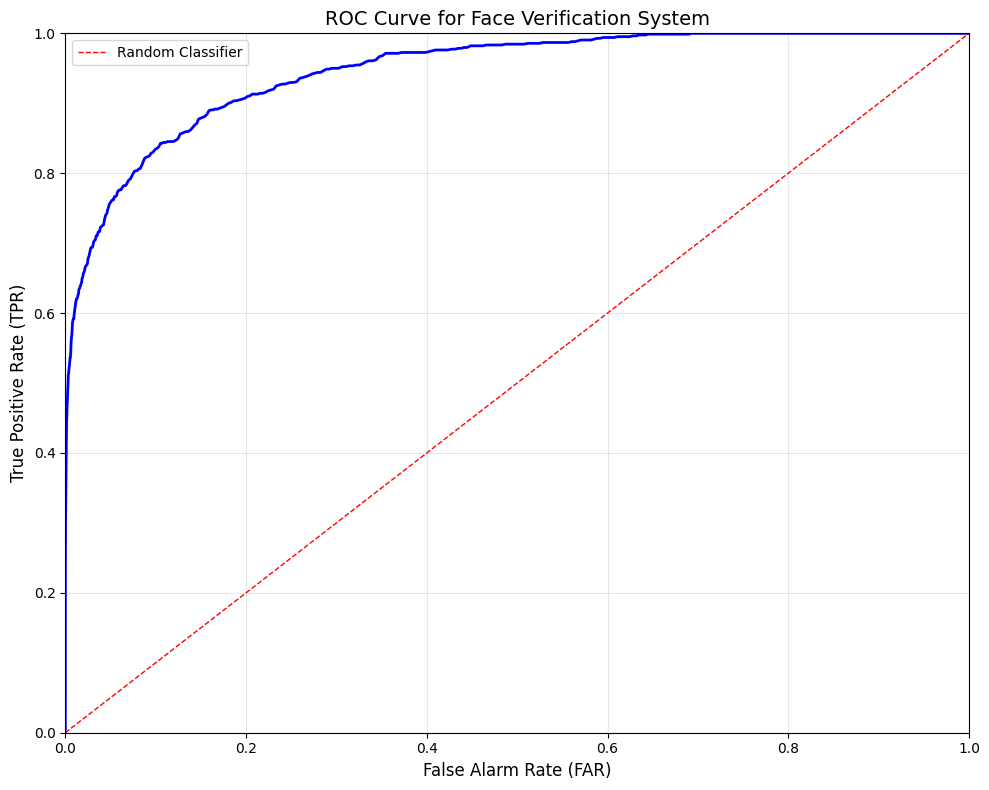


ROC Curve Statistics:
Number of thresholds tested: 1000
Threshold range: [1.7420, 17.5417]
Best TPR achieved: 1.0000
FAR at best TPR: 0.6931


In [12]:
def plot_roc_curve(A, num_thresholds=1000):
    """
    Generate and plot the ROC curve for face verification system.
    
    Parameters:
    A: Similarity matrix (shape: 120 x 280) where A[i,j] is Euclidean distance
    num_thresholds: Number of threshold levels to test (default: 1000)
    
    Returns:
    None (displays plot)
    """
    # Find min and max distances in the similarity matrix
    min_threshold = np.min(A)
    max_threshold = np.max(A)
    
    print(f"Minimum threshold: {min_threshold:.4f}")
    print(f"Maximum threshold: {max_threshold:.4f}")
    
    # Generate equally spaced thresholds
    thresholds = np.linspace(min_threshold, max_threshold, num_thresholds)
    
    # Store TPR and FAR for each threshold
    tpr_list = []
    far_list = []
    
    # Compute verification rates for each threshold
    for threshold in thresholds:
        tpr, far = compute_verification_rates(A, threshold)
        tpr_list.append(tpr)
        far_list.append(far)
    
    # Plot ROC curve
    plt.figure(figsize=(10, 8))
    plt.plot(far_list, tpr_list, 'b-', linewidth=2)
    plt.xlabel('False Alarm Rate (FAR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title('ROC Curve for Face Verification System', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    
    # Add diagonal reference line (random classifier)
    plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
    plt.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print some key statistics
    print(f"\nROC Curve Statistics:")
    print(f"Number of thresholds tested: {num_thresholds}")
    print(f"Threshold range: [{min_threshold:.4f}, {max_threshold:.4f}]")
    print(f"Best TPR achieved: {max(tpr_list):.4f}")
    print(f"FAR at best TPR: {far_list[np.argmax(tpr_list)]:.4f}")

# Generate and plot ROC curve with 1000 threshold levels
plot_roc_curve(A, num_thresholds=1000)

### Compute the mean vector from the training images. Show the vector as an image 
(use “numpy.reshape()”). This is typically called the meanface (or meanvoice for speech signals)

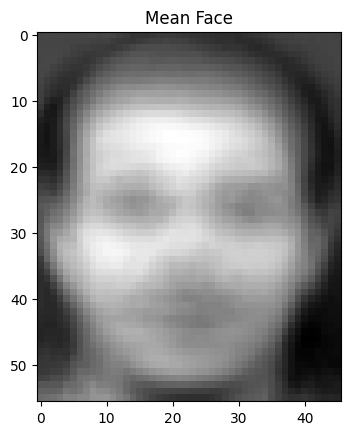

In [13]:
mean_face = np.mean(T, axis=0)

# Display the mean face
plt.imshow(mean_face, cmap="gray")
plt.title("Mean Face")
plt.show()

In [14]:
# Center the training data by subtracting the mean face
X_centered = np.array([img.flatten() - mean_face.flatten() for img in T])

# Compute the covariance matrix
cov_matrix = np.cov(X_centered.T)

# Compute eigenvalues and eigenvectors of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvectors by eigenvalues in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]
eigenvalues = eigenvalues[idx]

# The PCA vectors (principal components) are the eigenvectors
pca_vectors = eigenvectors

In [15]:
cov_matrix.shape, pca_vectors.shape

((2576, 2576), (2576, 2576))

In [16]:
rank_cov = np.linalg.matrix_rank(cov_matrix)
print("Rank of the covariance matrix:", rank_cov)

Rank of the covariance matrix: 119


Gram matrix G shape: (120, 120)
Top eigenvalues (Gram): [1423.92971484  875.37517697  558.62440028  407.34715673  371.02127373]
Eigenfaces shape: (2576, 120)


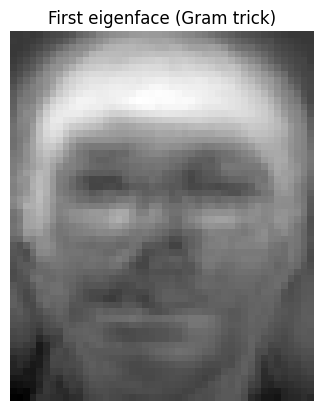

In [17]:
# Use Gram matrix trick for PCA with many features and fewer samples.
# Current X_centered has shape (120, 2576): samples in rows.
X_mat = X_centered.T  # shape (2576, 120), columns are zero-mean samples.

# Gram matrix in sample space (small 120x120 matrix)
G = X_mat.T @ X_mat
print("Gram matrix G shape:", G.shape)

eigvals_g, eigvecs_g = np.linalg.eigh(G)
idx_g = np.argsort(eigvals_g)[::-1]
eigvals_g = eigvals_g[idx_g]
eigvecs_g = eigvecs_g[:, idx_g]

# Recover eigenvectors in original pixel space (eigenfaces)
eigenfaces_from_gram = X_mat @ eigvecs_g
norms = np.linalg.norm(eigenfaces_from_gram, axis=0, keepdims=True)
eigenfaces_from_gram = eigenfaces_from_gram / np.maximum(norms, 1e-12)

print("Top eigenvalues (Gram):", eigvals_g[:5])
print("Eigenfaces shape:", eigenfaces_from_gram.shape)

# Optional: display first eigenface
plt.imshow(eigenfaces_from_gram[:, 0].reshape(56, 46), cmap="gray")
plt.title("First eigenface (Gram trick)")
plt.axis("off")
plt.show()

Yes, `G` is symmetric.  
Because `G = X.T @ X` (where columns are centered samples), and for any matrix `M`, `(M.T @ M)` is always symmetric: `(M.T @ M).T = M.T @ (M.T).T = M.T @ M`.  
So `G[i,j] = dot(x_i, x_j) = G[j,i]`.

In [18]:
# Compute eigen-decomposition of Gram matrix G
eigvals_G, eigvecs_G = np.linalg.eigh(G)

# Sort eigenvalues/eigenvectors in descending order
idx = np.argsort(eigvals_G)[::-1]
eigvals_G = eigvals_G[idx]
eigvecs_G = eigvecs_G[:, idx]

# Treat very small values as zero
tol = 1e-10
nonzero_count = np.sum(eigvals_G > tol)

print("Number of non-zero eigenvalues (tol=1e-10):", nonzero_count)
print("Total eigenvalues:", eigvals_G.shape[0])
print("Top eigenvalues (desc):")
print(eigvals_G[:10])

# option to inspect smallest magnitudes
print("Smallest eigenvalues:")
print(eigvals_G[-10:])

Number of non-zero eigenvalues (tol=1e-10): 119
Total eigenvalues: 120
Top eigenvalues (desc):
[1423.92971484  875.37517697  558.62440028  407.34715673  371.02127373
  263.28080075  203.39698967  190.96510133  166.54805607  143.5705511 ]
Smallest eigenvalues:
[ 3.17991974e+00  3.13382008e+00  3.07484004e+00  2.73615457e+00
  2.57040486e+00  2.55027268e+00  2.09754295e+00  1.69989241e+00
  1.09424775e+00 -2.88491846e-14]


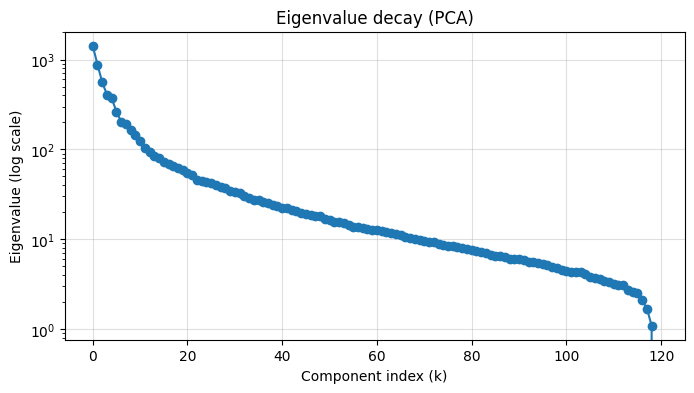

Total components: 120
Components needed for 95% variance: 64
Explained variance at k=64: 0.9515


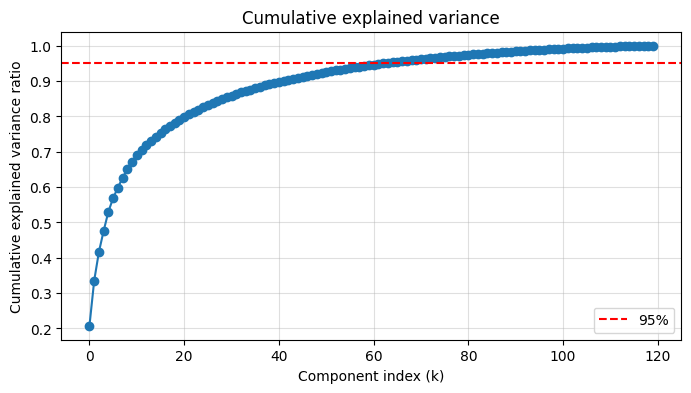

In [19]:
# plot the eigenvalues (from Gram matrix; they correspond to variance along principal components)
ev = eigvals_g.copy()  # already sorted descending in your session
plt.figure(figsize=(8, 4))
plt.plot(ev, marker='o', linestyle='-')
plt.yscale('log')
plt.xlabel('Component index (k)')
plt.ylabel('Eigenvalue (log scale)')
plt.title('Eigenvalue decay (PCA)')
plt.grid(True, alpha=0.4)
plt.show()

# cumulative variance ratio
total_var = np.sum(ev)
cum_var = np.cumsum(ev)
cum_ratio = cum_var / total_var

# find number of components needed for 95% variance
k_95 = np.searchsorted(cum_ratio, 0.95) + 1

print(f"Total components: {len(ev)}")
print(f"Components needed for 95% variance: {k_95}")
print(f"Explained variance at k={k_95}: {cum_ratio[k_95-1]:.4f}")

# optional: plot cumulative variance ratio
plt.figure(figsize=(8, 4))
plt.plot(cum_ratio, marker='o', linestyle='-')
plt.axhline(0.95, color='red', linestyle='--', label='95%')
plt.xlabel('Component index (k)')
plt.ylabel('Cumulative explained variance ratio')
plt.title('Cumulative explained variance')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

Original norms (first 10): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Normalized norms (first 10): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


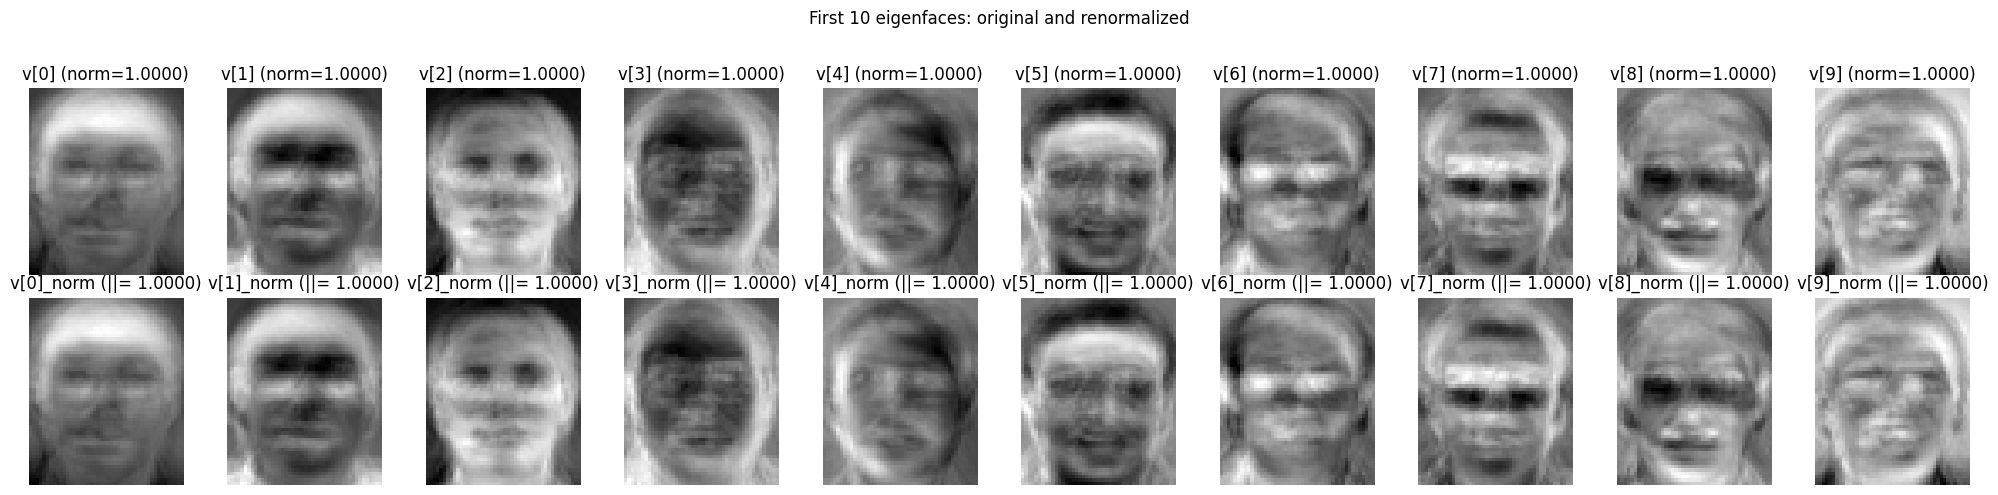

In [20]:
# using eigenfaces computed from the Gram trick as v⃑ (pixel-space eigenvectors)
v = eigenfaces_from_gram  # shape (2576, 120)
top_k = 10

# norms of original eigenvectors
norms_orig = np.linalg.norm(v[:, :top_k], axis=0)

# normalized versions (unit norm)
v_normed = v[:, :top_k] / norms_orig[np.newaxis, :]
norms_normed = np.linalg.norm(v_normed, axis=0)

print("Original norms (first 10):", np.round(norms_orig, 6))
print("Normalized norms (first 10):", np.round(norms_normed, 6))

# display first 10 eigenfaces: row 1 raw, row 2 normalized
fig, axes = plt.subplots(2, top_k, figsize=(20, 5))
for i in range(top_k):
    ax = axes[0, i]
    ax.imshow(v[:, i].reshape(56, 46), cmap="gray")
    ax.set_title(f"v[{i}] (norm={norms_orig[i]:.4f})")
    ax.axis("off")
    ax = axes[1, i]
    ax.imshow(v_normed[:, i].reshape(56, 46), cmap="gray")
    ax.set_title(f"v[{i}]_norm (||= {norms_normed[i]:.4f})")
    ax.axis("off")

plt.suptitle("First 10 eigenfaces: original and renormalized")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [21]:
# Project training images onto the first k=10 principal components
k = 10
T_proj = []
for img in T:
    centered = img.flatten() - mean_face.flatten()
    coeffs = v_normed.T @ centered
    T_proj.append(coeffs)

# Project testing images onto the first k=10 principal components
D_proj = []
for img in D:
    centered = img.flatten() - mean_face.flatten()
    coeffs = v_normed.T @ centered
    D_proj.append(coeffs)

# Compute similarity matrix using PCA projections
A_pca = compute_similarity_matrix(T_proj, D_proj)

print("PCA-based similarity matrix shape:", A_pca.shape)

# Compute verification rates for threshold t = 10 using PCA projections
threshold = 10
tpr_pca, far_pca = compute_verification_rates(A_pca, threshold)

print(f"Threshold t = {threshold} (PCA-based)")
print(f"True Positive Rate (TPR): {tpr_pca:.4f}")
print(f"False Alarm Rate (FAR): {far_pca:.4f}")

PCA-based similarity matrix shape: (120, 280)
Threshold t = 10 (PCA-based)
True Positive Rate (TPR): 1.0000
False Alarm Rate (FAR): 0.7792


MSE for k=10: 0.006148


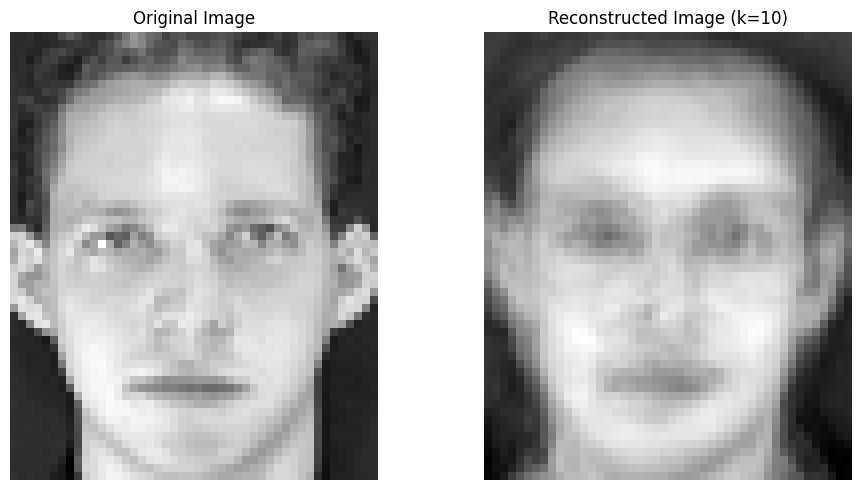

In [22]:
# Reconstruct the first training image using k=10 principal components
k = 10

# Get the first training image
first_img = T[0]

# Center it
centered_first = first_img.flatten() - mean_face.flatten()

# Project onto first k principal components
coeffs_first = v_normed[:, :k].T @ centered_first

# Reconstruct: coefficients * principal components
reconstructed_flat = v_normed[:, :k] @ coeffs_first

# Add back the mean face
reconstructed_flat = reconstructed_flat + mean_face.flatten()

# Reshape to image dimensions
reconstructed_img = reconstructed_flat.reshape(56, 46)

# Compute MSE between original and reconstructed
mse = np.mean((first_img - reconstructed_img) ** 2)

print(f"MSE for k={k}: {mse:.6f}")

# Visualize original and reconstructed
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(first_img, cmap="gray")
axes[0].set_title(f"Original Image")
axes[0].axis("off")
axes[1].imshow(reconstructed_img, cmap="gray")
axes[1].set_title(f"Reconstructed Image (k={k})")
axes[1].axis("off")
plt.tight_layout()
plt.show()